In [1]:
#------------------------------------------------------------------------------
#Here's the validation block on its own. It includes everything necessary from main the script up through the min_modulus definition (it needs chi_poly, required_prec, min_modulus, and the exact-data block that builds deformed_h_list):

#------------------------------------------------------------------------------------------------------
# ===== Min-moduli precision validation (c = 1), standalone =====
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial)

x    = polygen(QQ)
NMAX = 500          # must cover the largest n in `sample` below
c    = 1
ACCURACY_BITS = 60
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# ---- exact data (no precision loss here) ----
D = delta_qexp(nth_prime(NMAX) + 2)
h_list = [QQ(1)] + [QQ(D[nth_prime(k) + 1]) for k in range(1, NMAX + 1)]
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---- the validation ----
def validate(sample=(150, 300, 500), extra=256):
    print("  n    prec    min modulus            rel. drift   verdict")
    for n in sample:
        chi  = chi_poly(n)
        prec = required_prec(chi)
        mu   = min_modulus(chi, prec)
        mu2  = min_modulus(chi, prec + extra)
        rel  = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
        verdict = "OK" if rel < 1e-12 else "RAISE ACCURACY_BITS"
        print("%3d  %6d  %-22.14f  %.2e   %s"
              % (n, prec, float(mu), float(rel), verdict))

validate()

  n    prec    min modulus            rel. drift   verdict
150    2151  10352.82693697069044    0.00e+00   OK
300    4519  21091.01900291202401    0.00e+00   OK
500    7846  35422.91849324100622    0.00e+00   OK


n=  1 prec=   92 mu=1.000000 elapsed=0.0min
n=  2 prec=   99 mu=15.905974 elapsed=0.0min
n=  3 prec=  109 mu=45.110125 elapsed=0.0min
n=  4 prec=  118 mu=90.880224 elapsed=0.0min
n=  5 prec=  128 mu=138.751000 elapsed=0.0min
n=  6 prec=  138 mu=196.698201 elapsed=0.0min
n=  7 prec=  149 mu=252.401493 elapsed=0.0min
n=  8 prec=  160 mu=315.815143 elapsed=0.0min
n=  9 prec=  171 mu=375.661230 elapsed=0.0min
n= 10 prec=  182 mu=441.926874 elapsed=0.0min
n= 11 prec=  193 mu=504.289312 elapsed=0.0min
n= 12 prec=  205 mu=572.213394 elapsed=0.0min
n= 13 prec=  216 mu=636.249269 elapsed=0.0min
n= 14 prec=  228 mu=705.215839 elapsed=0.0min
n= 15 prec=  240 mu=770.437580 elapsed=0.0min
n= 16 prec=  252 mu=840.098518 elapsed=0.0min
n= 17 prec=  264 mu=906.200913 elapsed=0.0min
n= 18 prec=  276 mu=976.345399 elapsed=0.0min
n= 19 prec=  288 mu=1043.125689 elapsed=0.0min
n= 20 prec=  300 mu=1113.618974 elapsed=0.0min
n= 21 prec=  313 mu=1180.936083 elapsed=0.0min
n= 22 prec=  325 mu=1251.688231 elap

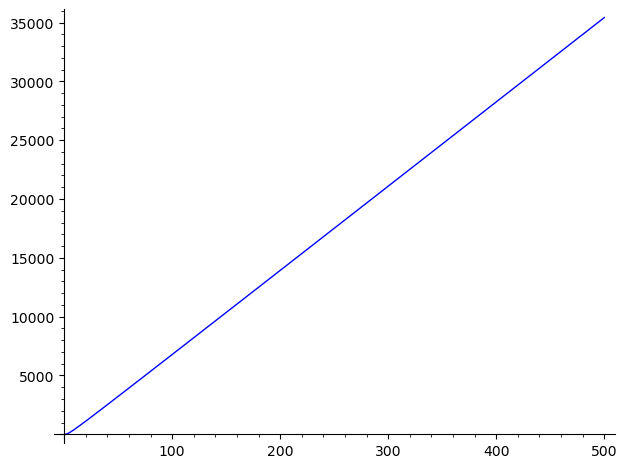

In [1]:
# ===== Oscillating spectra: min-moduli with adaptive precision (c = 1) =====
import time
from sage.all import (QQ, polygen, ComplexField, delta_qexp,
                      nth_prime, binomial, factorial, list_plot)

x    = polygen(QQ)
NMAX = 500
c    = 1
ACCURACY_BITS = 60   # trustworthy bits wanted in each min modulus (40-80 ample)
GUARD_BITS    = 32

def h_sequence_from_j(j_list):
    L = len(j_list); h = [QQ(1)]
    for n in range(1, L + 1):
        s = sum(j_list[r-1]*h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s)/n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1: raise ValueError("need h_0 = 1")
    L = len(h_list) - 1; j = []
    for n in range(1, L + 1):
        s = sum(j[r-1]*h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# ---- exact data: NO precision loss happens in this block ----
D = delta_qexp(nth_prime(NMAX) + 2)
h_list = [QQ(1)] + [QQ(D[nth_prime(k) + 1]) for k in range(1, NMAX + 1)]
j_list = j_sequence_from_h(h_list)
deformed_h_list = h_sequence_from_j([QQ(c)] + j_list)
def deformed_h(n): return deformed_h_list[n]

def chi_poly(n):
    return sum(binomial(n, r)*factorial(r)*deformed_h(r)*(-1)**r * x**(n - r)
               for r in range(n + 1))

def required_prec(chi):
    # base-2 size of the largest coefficient = dynamic range of the problem
    span = max(cf.numerator().abs().nbits() - cf.denominator().nbits()
               for cf in chi.coefficients())
    return int(span) + ACCURACY_BITS + GUARD_BITS

def min_modulus(chi, prec):
    CC = ComplexField(prec)
    return min(r.abs() for r in chi.roots(ring=CC, multiplicities=False))

# ---------- VALIDATE precision before committing to the full run ----------
# Recompute a few n at prec and prec+256. Tiny relative drift => adequate.
# If mu is *unchanged from your old 100-bit value*, roots() isn't honoring
# the field precision -> use the PARI fallback noted below.
#for n in (150, 300, 500):
#    chi  = chi_poly(n)
#    prec = required_prec(chi)
#    mu, mu2 = min_modulus(chi, prec), min_modulus(chi, prec + 256)
#    rel = abs(mu - mu2)/mu2 if mu2 != 0 else abs(mu - mu2)
#    print("n=%3d  prec=%5d  mu=%.10f  rel.drift=%.2e" % (n, prec, mu, rel))

# ---------- MAIN RUN ----------
start = time.time(); mins_list = []
for n in range(1, NMAX + 1):
    chi  = chi_poly(n)
    mu   = min_modulus(chi, required_prec(chi))
    mins_list.append((n, float(mu)))
  
    if n % 1 == 0:
        print("n=%3d prec=%5d mu=%.6f elapsed=%.1fmin"
              % (n, required_prec(chi_poly(n)), mu, (time.time() - start)/60))

print("MINIMUM MODULI")
list_plot(mins_list, plotjoined=True, axes_labels=['', '']).show()